In [32]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(vals, mu, sigma):
    return np.exp(-(vals - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))


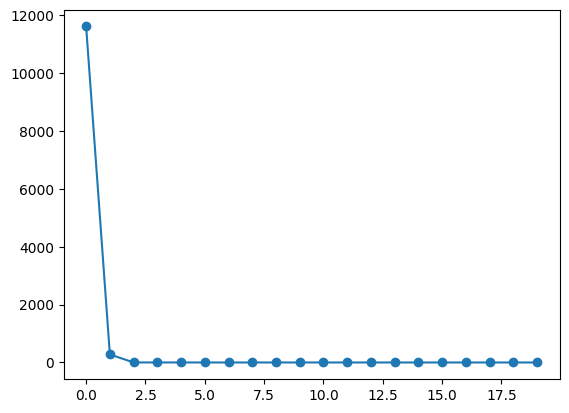

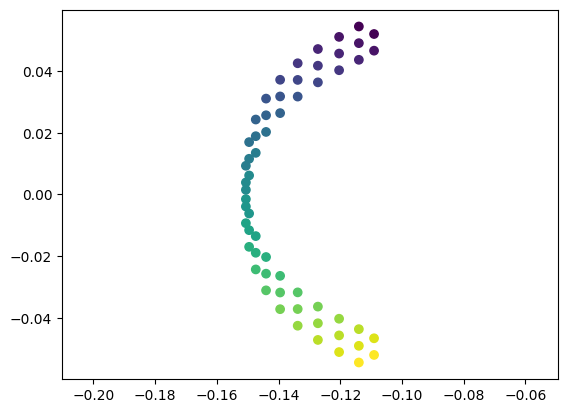

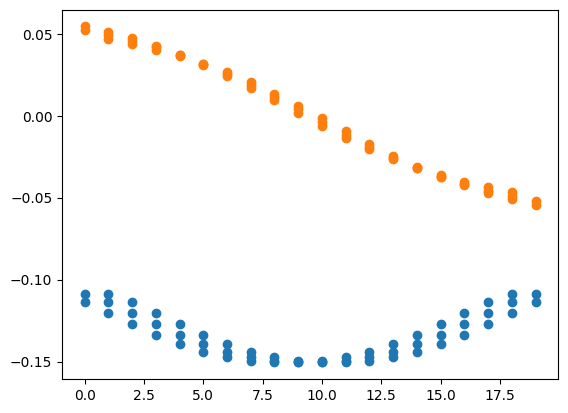

In [40]:
S = 20
A = 1

sigma = 10

actions = np.arange(-A, A+1)
s_obs = np.zeros((S, S))
for s_curr in range(S):
    for s_val in range(S):
        s_obs[s_curr, s_val] = gaussian(s_val, s_curr, sigma)

X = []
y = []
loc_y = []
for s in range(S):
    for a in actions:
        s_next = s + a
        if s_next < 0 or s_next > S-1:
            continue
        X.append(np.concatenate([s_obs[s], [a]]))
        y.append(s_obs[s_next])
        loc_y.append(s_next)

X = np.array(X)
y = np.array(y)
loc_y = np.array(loc_y)

OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
U, L, V = np.linalg.svd(OLS)
plt.plot(L, marker='o')
plt.show()

plt.scatter(X@U[:,0]*L[0], X@U[:,1]*L[1], c=loc_y)
plt.axis('equal')
plt.show()

plt.scatter(loc_y, X@U[:,0]*L[0])
plt.scatter(loc_y, X@U[:,1]*L[1])
